# Truth-vs-estimated per-record AF on 8 SEEDMIX replicates (Chr1 SNPs)

For each of SEEDMIX_S1..S8 we show **four** scatters:
1. cactus_em vs recipe-projected expectation (truth = 1/231 @ cn_var_v3)
2. cactus_em-**filt2** vs recipe
3. cactus_em vs **hapFIRE per-SNP AF** (method comparison)
4. cactus_em-**filt2** vs **hapFIRE** (does filt2 increase agreement with hapFIRE?)

Reads are Trimmomatic + Clumpify-deduped.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/global/scratch/users/tbellg/hapfire_sv')
CEM_DIR = ROOT / 'scratch/seedmix_v3_dedup'
CEM_FILT2_DIR = ROOT / 'scratch/seedmix_v3_filt2_dedup'
HF_DIR = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix')
CN_VAR = ROOT / 'poolfreq/data/cn_var_231_v3.cn_var.npz'
CN_VAR_META = ROOT / 'poolfreq/data/cn_var_231_v3.meta.npz'

meta = np.load(CN_VAR_META, allow_pickle=True)
rec_chrom = np.asarray(meta['chrom']).astype(str)
rec_pos   = np.asarray(meta['pos']).astype(np.int64)
rec_rlen  = np.asarray(meta['ref_len']).astype(np.int32)
rec_alen  = np.asarray(meta['alt_len']).astype(np.int32)

chr1_snp_mask = (rec_chrom == 'Chr1') & (rec_rlen == 1) & (rec_alen == 1)
chr1_snp_idx = np.where(chr1_snp_mask)[0]
chr1_snp_pos = rec_pos[chr1_snp_idx]
print(f'Chr1 SNP records in cn_var_v3: {len(chr1_snp_idx):,}')

cn_var = load_npz(CN_VAR)
F = cn_var.shape[0]
TRUTH_H = np.full(F, 1.0/F, dtype=np.float32)
cv_chr1_snps = cn_var[:, chr1_snp_idx].toarray().astype(np.float32)
truth_af = TRUTH_H @ cv_chr1_snps
print(f'recipe-projected truth_af: min={truth_af.min():.4f}, max={truth_af.max():.4f}, mean={truth_af.mean():.4f}')


Chr1 SNP records in cn_var_v3: 983,431


recipe-projected truth_af: min=0.0000, max=1.0000, mean=0.0972


In [2]:
def load_cem_chr1_snp_af(d, s):
    df = pd.read_csv(d / f'SEEDMIX_S{s}.tsv', sep='\t')
    return df['alt_freq'].to_numpy()[chr1_snp_idx]

def load_hapfire_chr1_af(s):
    df = pd.read_csv(HF_DIR / f's{s}_snp_frequency.txt', sep='\t',
                     header=None, names=['chrom','pos','af'])
    df = df[df['chrom'].astype(str) == '1']
    return dict(zip(df['pos'].astype(np.int64), df['af'].astype(np.float32)))

cem_af   = {s: load_cem_chr1_snp_af(CEM_DIR, s) for s in range(1, 9)}
filt2_af = {s: load_cem_chr1_snp_af(CEM_FILT2_DIR, s) for s in range(1, 9)}
hf_af_d  = {s: load_hapfire_chr1_af(s) for s in range(1, 9)}

# Precompute hapFIRE AF aligned to chr1_snp_pos
hf_af_aligned = {}
for s in range(1, 9):
    d = hf_af_d[s]
    hf_af_aligned[s] = np.array([d.get(p, np.nan) for p in chr1_snp_pos], dtype=np.float32)
print('loaded all 8 reps × 3 methods')


loaded all 8 reps × 3 methods


## Per-replicate quadruplet of scatters

Each row = one replicate; 4 columns:
- Col 1: cactus_em vs recipe
- Col 2: cactus_em-filt2 vs recipe
- Col 3: cactus_em vs hapFIRE
- Col 4: cactus_em-filt2 vs hapFIRE


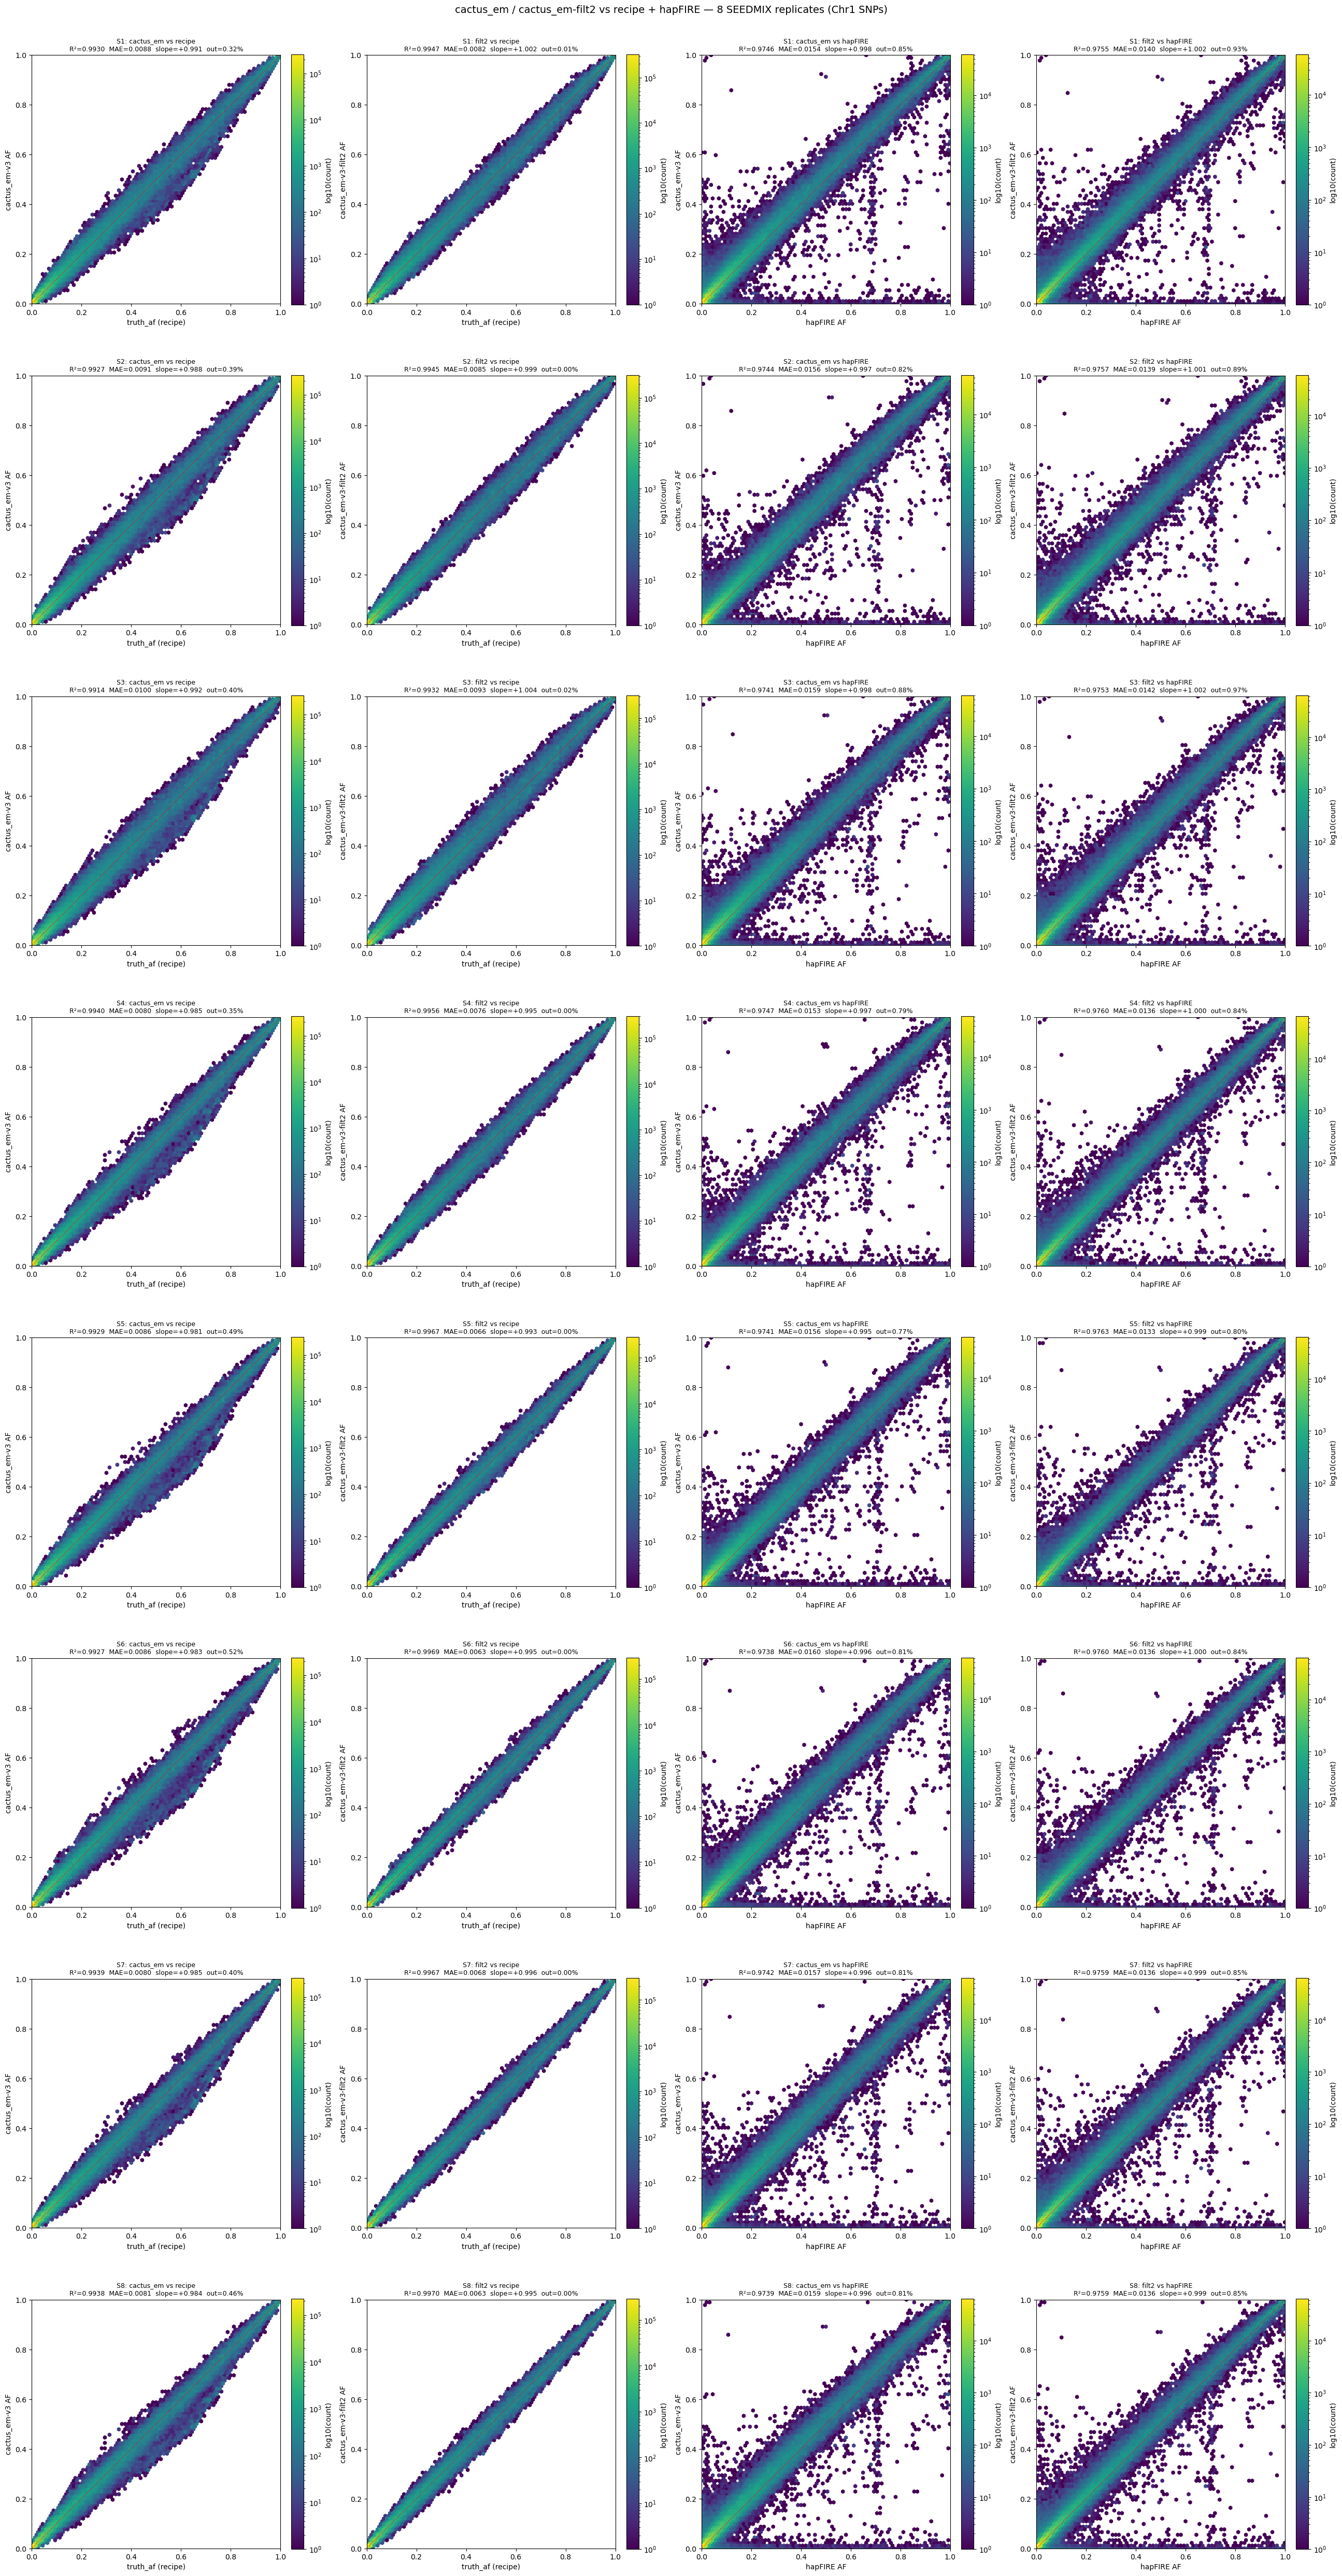

In [3]:
def metrics(x, y):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if finite.sum() < 5: return None
    xv = x[finite]; yv = y[finite]
    return dict(
        n=int(finite.sum()),
        r2=float(np.corrcoef(xv, yv)[0,1]**2),
        mae=float(np.mean(np.abs(yv - xv))),
        slope=float(np.polyfit(xv, yv, 1)[0]),
        out=float(np.mean(np.abs(yv - xv) > 0.1)),
    )

def hexbin(ax, x, y, xlabel, ylabel, title):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if finite.sum() < 5:
        ax.text(0.5, 0.5, 'no overlap', ha='center', va='center')
        return
    hb = ax.hexbin(x[finite], y[finite], gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    m = metrics(x, y)
    ax.set_title(f'{title}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  slope={m["slope"]:+.3f}  '
                 f'out={100*m["out"]:.2f}%', fontsize=9)
    plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)

# 8 rows × 4 cols
fig, axes = plt.subplots(8, 4, figsize=(26, 50))

for s in range(1, 9):
    row = s - 1
    cem = cem_af[s]
    f2  = filt2_af[s]
    hf  = hf_af_aligned[s]

    hexbin(axes[row, 0], truth_af, cem,
           'truth_af (recipe)', 'cactus_em-v3 AF',
           f'S{s}: cactus_em vs recipe')
    hexbin(axes[row, 1], truth_af, f2,
           'truth_af (recipe)', 'cactus_em-v3-filt2 AF',
           f'S{s}: filt2 vs recipe')
    hexbin(axes[row, 2], hf, cem,
           'hapFIRE AF', 'cactus_em-v3 AF',
           f'S{s}: cactus_em vs hapFIRE')
    hexbin(axes[row, 3], hf, f2,
           'hapFIRE AF', 'cactus_em-v3-filt2 AF',
           f'S{s}: filt2 vs hapFIRE')

fig.suptitle('cactus_em / cactus_em-filt2 vs recipe + hapFIRE — 8 SEEDMIX replicates (Chr1 SNPs)',
              y=0.998, fontsize=14)
plt.tight_layout()
plt.show()


## Cross-replicate summary


In [4]:
rows = []
for s in range(1, 9):
    cem = cem_af[s]; f2 = filt2_af[s]; hf = hf_af_aligned[s]
    for comp_label, comp in [('recipe', truth_af), ('hapFIRE', hf)]:
        for method_label, est in [('cactus_em', cem), ('cactus_em-filt2', f2)]:
            m = metrics(comp, est)
            if m is None: continue
            rows.append(dict(replicate=s, comparator=comp_label, method=method_label,
                             n=m['n'], r2=m['r2'], mae=m['mae'],
                             slope=m['slope'], out_pct=100*m['out']))
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format='%.4f'))


 replicate comparator          method      n     r2    mae  slope  out_pct
         1     recipe       cactus_em 983431 0.9930 0.0088 0.9913   0.3227
         1     recipe cactus_em-filt2 983431 0.9947 0.0082 1.0017   0.0053
         1    hapFIRE       cactus_em 441280 0.9746 0.0154 0.9984   0.8539
         1    hapFIRE cactus_em-filt2 441280 0.9755 0.0140 1.0017   0.9289
         2     recipe       cactus_em 983431 0.9927 0.0091 0.9880   0.3891
         2     recipe cactus_em-filt2 983431 0.9945 0.0085 0.9986   0.0036
         2    hapFIRE       cactus_em 441280 0.9744 0.0156 0.9971   0.8208
         2    hapFIRE cactus_em-filt2 441280 0.9757 0.0139 1.0007   0.8863
         3     recipe       cactus_em 983431 0.9914 0.0100 0.9920   0.3966
         3     recipe cactus_em-filt2 983431 0.9932 0.0093 1.0035   0.0173
         3    hapFIRE       cactus_em 441280 0.9741 0.0159 0.9976   0.8829
         3    hapFIRE cactus_em-filt2 441280 0.9753 0.0142 1.0018   0.9679
         4     recipe    

## Diagnostic — per-record cn_var v3 vs GN carrier-count AF (no EM)

Comparing **raw cn_var carrier fractions** (not EM-output AF). At each matched
Chr1 SNP, compute `v3_af = v3_carriers/231` and `gn_af = gn_carriers/231`.

Shows the PANEL-level disagreement that the directionality test summed up. The
expected reconciliation: most records have small positive diff (v3 has 1-2 extra
carriers) but a small number of records have large negative diff (v3 has many
fewer carriers — atomization or whatever loss mechanism).


Loaded 436,927 matched-SNP per-record AF diffs.


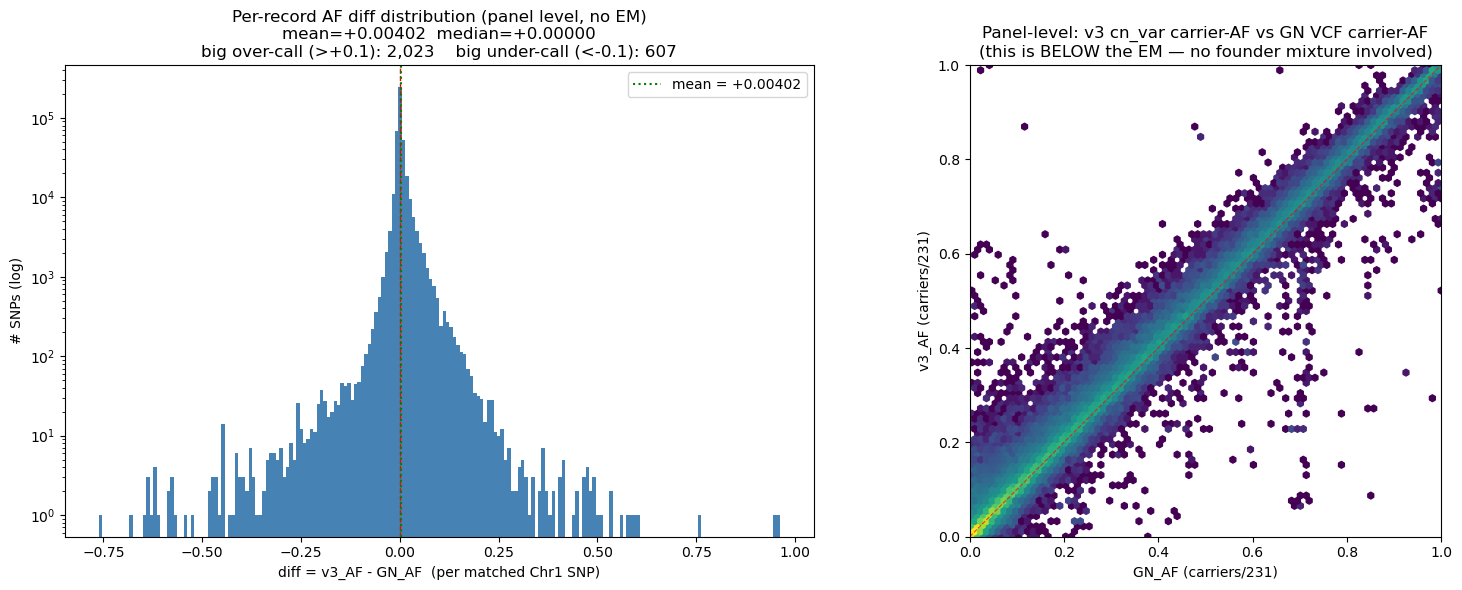

In [5]:
# Load the precomputed per-record AF diff (from scratch/v3_vs_gn_per_record_af.npz)
path = ROOT / 'scratch/v3_vs_gn_per_record_af.npz'
if path.exists():
    z = np.load(path)
    v3_af_panel = z['v3_af']
    gn_af_panel = z['gn_af']
    diff_panel = z['diff']
    print(f'Loaded {len(diff_panel):,} matched-SNP per-record AF diffs.')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    # Histogram of diff
    axes[0].hist(diff_panel, bins=200, color='steelblue', edgecolor='none')
    axes[0].axvline(0, color='red', linestyle='--', lw=1)
    axes[0].axvline(diff_panel.mean(), color='green', linestyle=':', lw=1.5,
                    label=f'mean = {diff_panel.mean():+.5f}')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('diff = v3_AF - GN_AF  (per matched Chr1 SNP)')
    axes[0].set_ylabel('# SNPs (log)')
    axes[0].set_title(f'Per-record AF diff distribution (panel level, no EM)\n'
                       f'mean={diff_panel.mean():+.5f}  median={np.median(diff_panel):+.5f}\n'
                       f'big over-call (>+0.1): {(diff_panel>0.1).sum():,}    '
                       f'big under-call (<-0.1): {(diff_panel<-0.1).sum():,}')
    axes[0].legend()

    # Scatter
    axes[1].hexbin(gn_af_panel, v3_af_panel, gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1)
    axes[1].plot([0,1],[0,1],'r--', lw=0.8, alpha=0.7)
    axes[1].set_xlim(0,1); axes[1].set_ylim(0,1); axes[1].set_aspect('equal')
    axes[1].set_xlabel('GN_AF (carriers/231)')
    axes[1].set_ylabel('v3_AF (carriers/231)')
    axes[1].set_title('Panel-level: v3 cn_var carrier-AF vs GN VCF carrier-AF\n(this is BELOW the EM — no founder mixture involved)')
    plt.tight_layout()
    plt.show()
else:
    print('scratch/v3_vs_gn_per_record_af.npz not found; run the diagnostic script first.')
